# 10 · E3: program versus hardware

**The question (proposal §4, E3).** In a computer, the transfer function is fixed on the timescale of the computation: the program does not rewrite the machine it runs on. Brette's central objection is that in a brain the "hardware" is continuously rebuilt by its own activity. E3 turns this into a measurement on spontaneous whole-brain activity.

**Design.** A connectome-constrained dynamical model, dx = −a·x + W·tanh(x) + b + noise, with W on the wiring, is used to **forecast forward in time**: fitted only on the past, and scored on later windows that it has never seen.

| model | what it is | state it needs per recording |
|---|---|---|
| **frozen** | one fixed program (a, W, b) | none beyond the program |
| **refit** | the same program, with its N drives re-estimated in every window: the hardware is rewritten | N new numbers per window, so it **grows with recording length** |
| **meta(d)** | fixed program + d slow states, driven by the activity itself, that modulate the drives: **self-programming** | d fixed rules, **constant** |

**Verdicts (pre-registered).**
* **stationary:** a fixed program forecasts as well as a rewritten one; C3 holds trivially.
* **self_program:** drift exists, but a compact meta-program (d ≤ 4) absorbs at least half of it. The computer metaphor survives as self-programming.
* **rewired:** drift exists that no compact activity-driven meta-program absorbs. The program/hardware distinction fails for this system.

**Why E3 now.** E1 found that on stimulation data the closed level is bracketed **L0 ≤ closed ≤ L1**, and that deeper mechanisms cannot be identified from this kind of experiment (Notebooks 06–09). E3 asks a different question that does not need that identification: *whatever the closed level is, does it stay fixed?* Spontaneous recordings are long, and that is exactly what E3 needs.

**Structure.**
* §1 validates the pipeline on synthetic worms with known answers.
* §2 shows how absorption scales with recording length.
* §3 runs on real recordings (Atanas et al. 2023) once you have downloaded them.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, time, datetime, numpy as np, matplotlib.pyplot as plt
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:2]) >= (0, 9), \
    f"Notebook 10 needs closurebench >= 0.9 (found {closurebench.__version__}); copy the full package and restart the kernel"
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 9, 1), \
    f"Notebook 10 needs closurebench >= 0.9.1 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, drift as DR
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {
    "smoke":  dict(N_NEURONS=16, REAL_WIRING=False, T=800,  NULL_SEEDS=[11], TEST_SEEDS=[1], META_STEPS=200, D_GRID=(1, 2), N_SURR=1),
    "laptop": dict(N_NEURONS=60, REAL_WIRING=True,  T=1600, NULL_SEEDS=[11, 12, 13], TEST_SEEDS=[1, 2, 3], META_STEPS=3000, D_GRID=(1, 2, 4), N_SURR=3),
    "full":   dict(N_NEURONS=120, REAL_WIRING=True, T=1600, NULL_SEEDS=[11, 12, 13, 14, 15], TEST_SEEDS=[1, 2, 3, 4, 5], META_STEPS=4000, D_GRID=(1, 2, 4), N_SURR=5),
}[MODE]
globals().update(CONF)
KINDS = ["stationary", "self_program", "rewired"]
N_WINDOWS, ABSORB_MIN, D_MAX = 8, 0.5, 4
TAG = "" if MODE == "full" else f"_{MODE}"
ds_path = os.path.join(RESULTS, "atlas_dataset.npz")
real = D.Dataset.load(ds_path) if os.path.exists(ds_path) else D.load_atlas_dataset()
if REAL_WIRING:
    mk = real.mask()[0]; score = mk.sum(1).astype(float); score[real.stim] += mk.sum(0)
    template = D.subset(real, np.sort(np.argsort(-score)[:N_NEURONS]))
else:
    template = lad.random_wiring(N=N_NEURONS, seed=0, trials=4)
S = (np.asarray(template.chem) > 0) | (np.asarray(template.gap) > 0); S = S | S.T
print(f"template: {template.N} neurons, {int(S.sum()) // 2} coupled pairs; recordings of {T} frames (dt = 0.6 s, {T * 0.6 / 60:.0f} min)")

def run(kind, seed):
    W = DR.connectome_matrix(template, np.random.default_rng(seed))
    X = DR.simulate(W, kind, T=T, seed=seed)
    return DR.analyse(X, S, n_windows=N_WINDOWS, d_grid=D_GRID, meta_steps=META_STEPS, seed=seed)

template: 60 neurons, 286 coupled pairs; recordings of 1600 frames (dt = 0.6 s, 16 min)


### Pre-registration (before §1)

Recorded in `results/E3_preregistration*.json`:

* **Drift threshold.** gap_min = the largest refit − frozen forecast gap over the stationary null worms (`NULL_SEEDS`), never below 0.005.
* **Classification.**
  * stationary if gap < gap_min;
  * otherwise self_program if some meta(d ≤ 4) absorbs ≥ 0.5 of the gap;
  * otherwise rewired.
* **The pipeline is valid** if, on the test worms (`TEST_SEEDS`, all three kinds):
  * no stationary or rewired worm is classified self_program;
  * no stationary worm is classified as drifting;
  * at least 2/3 of the self_program worms are classified correctly.
* **Real data** are interpreted only if the pipeline is valid.

**Real-data procedure (rule v2; added after the first real files failed to load, before any real result existed).** The real recordings differ from the validation regime: about 140 neurons, no NeuroPAL labels (so all-to-all coupling instead of the connectome), and behavior available. Each recording therefore gets its own controls:
* **Primary verdict:** the same rule, with behavior (velocity, head angle, angular velocity, pumping) as inputs to every model. The drift threshold is gap_min_r = max(gap_min, the largest gap among `N_SURR` **stationary surrogates**, i.e. recordings simulated from the program fitted to that same recording).
* **Power check:** a **drifting surrogate** (the same program plus a random-walk drive change of the validated size, 0.07 × residual sd per step). If its gap stays below gap_min_r, the test has no power on that recording, and a "stationary" verdict is reported as "stationary (low power)".
* **Diagnostics (reported, not part of the verdict):**
  * *temporal generalization*: do programs fitted on one window go stale with distance? Compared with the surrogates, and again after removing trends slower than 4 min;
  * *staleness absorption*: does a meta-program fitted on the first half go stale more slowly than a frozen one?

**Code changes before real data (affect §1 too, which was re-validated, 9/9):**
* the ridge strength is chosen from the past only;
* the meta-program keeps the program's couplings fixed and learns only drives and slow states;
* the loader reads WormWideWeb's nested JSON.

In [3]:
prereg = os.path.join(RESULTS, f"E3_preregistration{TAG}.json")
plan = {"experiment": "E3 program vs hardware", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": {**CONF, "D_GRID": list(D_GRID), "N_WINDOWS": N_WINDOWS, "ABSORB_MIN": ABSORB_MIN, "D_MAX": D_MAX},
        "gap_min": "max refit-frozen gap over stationary null worms, floor 0.005",
        "classes": "stationary if gap < gap_min; else self_program if max_{d<=4} absorbed >= 0.5; else rewired",
        "validity": "test worms: no stationary/rewired -> self_program; no stationary -> drifting; >= 2/3 self_program correct",
        "real_data": "interpreted only if the pipeline is valid",
        "real_rule": "behavior as inputs; gap_min_r = max(gap_min, max gap of N_SURR stationary surrogates); "
                     "power check with a drifting surrogate (drift_frac 0.07): if undetected, 'stationary' -> 'stationary (low power)'; "
                     "temporal generalization, 4-min detrending and staleness absorption are diagnostics only",
        "rule_version": 2}
result_path = os.path.join(RESULTS, f"E3_result{TAG}.json")
def _has_real_results(p):
    try: return bool(json.load(open(p)).get("real"))
    except Exception: return False
if os.path.exists(prereg):
    old = json.load(open(prereg))
    if old.get("rule_version") == 2:
        plan = old; print("Existing registration (", plan["registered_at"], ") used unchanged.")
    elif _has_real_results(result_path):
        raise RuntimeError("An older registration exists AND real-data results were produced under it: inspect both before changing rules.")
    else:
        os.replace(prereg, prereg.replace(".json", "_superseded_v1.json")); json.dump(plan, open(prereg, "w"), indent=2)
        print("Older registration (v1, no real-data results) kept as *_superseded_v1.json; registered rule v2 ->", prereg)
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Older registration (v1, no real-data results) kept as *_superseded_v1.json; registered rule v2 -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E3_preregistration_laptop.json


## 1 · Synthetic validation

Three kinds of synthetic worm on the real wiring:
* **stationary:** fixed drives;
* **self_program:** drives modulated by 2 slow states driven by activity, with a 300-s timescale;
* **rewired:** each neuron's drive does its own random walk, independent of activity.

First the stationary null worms set gap_min, then the test worms are classified.

In [4]:
null = []
for seed in NULL_SEEDS:
    t0 = time.time(); r = run("stationary", seed); null.append(r["gap"])
    print(f"null (stationary) seed {seed}: gap {r['gap']:+.4f}  ({time.time() - t0:.0f} s)")
GAP_MIN = DR.calibrate_gap(null)
print(f"\ncalibrated gap_min = {GAP_MIN:.4f}")
results = {}
for kind in KINDS:
    for seed in TEST_SEEDS:
        t0 = time.time(); r = run(kind, seed); results[(kind, seed)] = r
        v = DR.verdict(r, gap_min=GAP_MIN, absorb_min=ABSORB_MIN, d_max=D_MAX)
        print(f"{kind:13s} seed {seed}: frozen {r['frozen']:.3f} refit {r['refit']:.3f} gap {r['gap']:+.4f} | absorbed "
              + " ".join(f"d={d}: {a:+.2f}" for d, a in r["absorbed"].items()) + f"  -> {v} {'✓' if v == kind else '✗'}  ({time.time() - t0:.0f} s)")

null (stationary) seed 11: gap -0.0068  (49 s)
null (stationary) seed 12: gap -0.0069  (48 s)
null (stationary) seed 13: gap -0.0078  (52 s)

calibrated gap_min = 0.0050
stationary    seed 1: frozen 0.169 refit 0.164 gap -0.0058 | absorbed d=1: +nan d=2: +nan d=4: +nan  -> stationary ✓  (49 s)
stationary    seed 2: frozen 0.163 refit 0.155 gap -0.0078 | absorbed d=1: +nan d=2: +nan d=4: +nan  -> stationary ✓  (46 s)
stationary    seed 3: frozen 0.164 refit 0.159 gap -0.0047 | absorbed d=1: +nan d=2: +nan d=4: +nan  -> stationary ✓  (47 s)
self_program  seed 1: frozen 0.101 refit 0.146 gap +0.0452 | absorbed d=1: +0.59 d=2: +0.76 d=4: +0.75  -> self_program ✓  (48 s)
self_program  seed 2: frozen 0.053 refit 0.100 gap +0.0476 | absorbed d=1: +0.15 d=2: +0.61 d=4: +0.61  -> self_program ✓  (46 s)
self_program  seed 3: frozen 0.143 refit 0.149 gap +0.0061 | absorbed d=1: +1.05 d=2: +1.07 d=4: +1.18  -> self_program ✓  (47 s)
rewired       seed 1: frozen 0.088 refit 0.123 gap +0.0346 | abso

{
 "stationary": [
  "stationary",
  "stationary",
  "stationary"
 ],
 "self_program": [
  "self_program",
  "self_program",
  "self_program"
 ],
 "rewired": [
  "rewired",
  "rewired",
  "rewired"
 ]
}

false 'self_program': 0 | stationary called drifting: 0 | self_program correct: 3/3
Registered rule -> pipeline valid: True


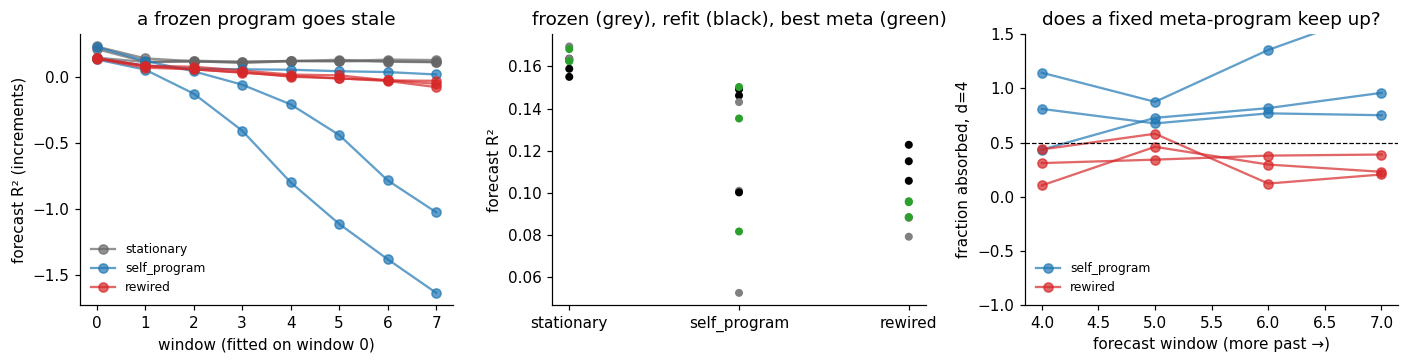

In [5]:
V = {k: [DR.verdict(results[(k, s)], gap_min=GAP_MIN, absorb_min=ABSORB_MIN, d_max=D_MAX) for s in TEST_SEEDS] for k in KINDS}
false_self = sum(v == "self_program" for k in ("stationary", "rewired") for v in V[k])
false_drift = sum(v != "stationary" for v in V["stationary"])
self_ok = sum(v == "self_program" for v in V["self_program"])
VALID = false_self == 0 and false_drift == 0 and self_ok >= int(np.ceil(2 / 3 * len(TEST_SEEDS)))
print(json.dumps(V, indent=1))
print(f"\nfalse 'self_program': {false_self} | stationary called drifting: {false_drift} | self_program correct: {self_ok}/{len(TEST_SEEDS)}")
print("Registered rule -> pipeline valid:", VALID)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for k, c in zip(KINDS, ["0.4", "tab:blue", "tab:red"]):
    for s in TEST_SEEDS:
        ax[0].plot(results[(k, s)]["decay"], "o-", c=c, alpha=0.7, label=k if s == TEST_SEEDS[0] else None)
ax[0].set_xlabel("window (fitted on window 0)"); ax[0].set_ylabel("forecast R² (increments)"); ax[0].set_title("a frozen program goes stale")
ax[0].legend(frameon=False, fontsize=8)
for j, k in enumerate(KINDS):
    for s in TEST_SEEDS:
        r = results[(k, s)]
        ax[1].scatter([j] * 3, [r["frozen"], r["refit"], max(r["meta"].values())], c=["0.5", "k", "tab:green"], s=18)
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(KINDS); ax[1].set_ylabel("forecast R²"); ax[1].set_title("frozen (grey), refit (black), best meta (green)")
for k, c in zip(KINDS[1:], ["tab:blue", "tab:red"]):
    for s in TEST_SEEDS:
        a = DR.absorption_by_window(results[(k, s)], max(D_GRID))
        ax[2].plot([w for w, _ in a], [v for _, v in a], "o-", c=c, alpha=0.7, label=k if s == TEST_SEEDS[0] else None)
ax[2].axhline(ABSORB_MIN, ls="--", c="k", lw=0.8); ax[2].set_ylim(-1, 1.5)
ax[2].set_xlabel("forecast window (more past →)"); ax[2].set_ylabel(f"fraction absorbed, d={max(D_GRID)}")
ax[2].set_title("does a fixed meta-program keep up?"); ax[2].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 2 · How the cost scales with recording length

The right panel above is the proposal's "decisive quantity", made operational:
* **self-programming:** the fraction absorbed by a *fixed-size* meta-program rises toward 1 as more past is available. The state needed stays constant (d) while the recording grows.
* **rewiring:** it stays near or below 0. Absorbing the drift would need the per-window refit, whose state grows by N numbers per window.

Note what this means for short recordings: a meta-program cannot be learned from less data than its own timescale. That is why forecasting starts at mid-recording, and it is a hard lower bound on recording length for the real data.

## 3 · Real spontaneous recordings

**Data.** The whole-brain recordings of Atanas et al. (2023, *Cell*) come from **WormWideWeb** (https://www.wormwideweb.org). Each file covers one freely moving animal: about 1,600 frames at 0.64 s (about 17 min) and 130–150 neurons, with behavior (velocity, head angle, angular velocity, pumping).
* Put the JSON files in `results/spontaneous/`.
* The loader reads `gcamp.trace_array`, `timing.mean_timestep` and `behavior`.
* It also accepts `.npz` files with `traces (T, N)`, `labels`, `dt` and optional `behavior (T, k)`.

**Neuron identities.** The baseline files contain no NeuroPAL labels, so the connectome cannot constrain the couplings. The model then uses **all-to-all coupling with a ridge penalty chosen from the past**. If a file does carry labels (`labeled`), the connectome support is used automatically.

**Caveats.**
* One-step forecasts are dominated by fast fluctuations, which makes them less sensitive to slow drift. This is why every recording gets a power check.
* GCaMP smooths and delays activity, and slow baseline changes (including bleaching) are not separable from slow neural states here; the detrending diagnostic shows how much of the drift lives in them.
* Behavior enters only as instantaneous inputs, not as slow behavioral states.

Runtime: about 3 minutes per recording on a laptop.

In [6]:
def detrend(X, w=400):
    """Remove trends slower than w frames (moving average), then z-score."""
    k = np.ones(w) / w; pad = np.pad(X, ((w // 2, w - 1 - w // 2), (0, 0)), mode="edge")
    trend = np.stack([np.convolve(pad[:, j], k, mode="valid") for j in range(X.shape[1])], 1)
    Y = X - trend; return (Y - Y.mean(0)) / (Y.std(0) + 1e-9)

files = sorted(glob.glob(os.path.join(RESULTS, "spontaneous", "*.json")) + glob.glob(os.path.join(RESULTS, "spontaneous", "*.npz")))
real_res = {}
if not files:
    print("No recordings in results/spontaneous/ yet: download from https://www.wormwideweb.org and re-run this cell.")
elif not VALID:
    print("The pipeline failed synthetic validation (§1): real recordings are not interpreted, by pre-registration.")
for f in files if VALID else []:
    name = os.path.basename(f).replace(".json", "").replace(".npz", "")
    try:
        X, labels, dt, U = DR.load_recording(f, behavior=True)
    except Exception as e:
        print(f"{name}: could not load ({e})"); continue
    t0 = time.time()
    S_r, n_id = DR.support_from_labels(labels, real)
    surr = [Y for Y in (DR.surrogate(X, S_r, U, seed=s) for s in range(N_SURR)) if Y is not None]
    pos = DR.surrogate(X, S_r, U, seed=100, drift_frac=0.07)
    gap_null = [DR.analyse(Y, S_r, n_windows=N_WINDOWS, d_grid=(), U=U)["gap"] for Y in surr]
    gap_min_r = max([GAP_MIN] + gap_null)
    gap_pos = DR.analyse(pos, S_r, n_windows=N_WINDOWS, d_grid=(), U=U)["gap"] if pos is not None else float("nan")
    powered = bool(gap_pos >= gap_min_r)
    r = DR.analyse(X, S_r, n_windows=N_WINDOWS, d_grid=D_GRID, meta_steps=META_STEPS, U=U)
    v = DR.verdict(r, gap_min=gap_min_r, absorb_min=ABSORB_MIN, d_max=D_MAX)
    if v == "stationary" and not powered:
        v = "stationary (low power)"
    # diagnostics (not part of the verdict)
    G, tg = DR.temporal_generalization(X, S_r, U, n_windows=N_WINDOWS)
    tg_null = [DR.temporal_generalization(Y, S_r, U, n_windows=N_WINDOWS)[1] for Y in surr]
    tg_pos = DR.temporal_generalization(pos, S_r, U, n_windows=N_WINDOWS)[1] if pos is not None else float("nan")
    tg_d = DR.temporal_generalization(detrend(X), S_r, U, n_windows=N_WINDOWS)[1]
    st = DR.staleness_absorption(X, S_r, U, d_grid=(max(D_GRID),), n_windows=N_WINDOWS, meta_steps=META_STEPS)
    real_res[name] = dict(r, verdict=v, T=X.shape[0], N=X.shape[1], identified=n_id, dt=dt, gap_min_r=gap_min_r, gap_null=gap_null,
                          gap_pos=gap_pos, powered=powered, tg=tg, tg_null=tg_null, tg_pos=tg_pos, tg_detrended=tg_d,
                          stale_frozen=st["slope_frozen"], stale_meta=st["slope_meta"][max(D_GRID)],
                          stale_absorbed=st["absorbed"][max(D_GRID)], G=G.tolist())
    print(f"{name}: N={X.shape[1]} ({n_id} identified), {X.shape[0] * dt / 60:.0f} min | gap {r['gap']:+.4f} vs threshold {gap_min_r:.4f} "
          f"(positive control {gap_pos:+.4f}) | absorbed d={max(D_GRID)}: {r['absorbed'][max(D_GRID)]:+.2f} -> {v}   "
          f"[TG slope {tg:+.4f}; null {min(tg_null) if tg_null else float('nan'):+.4f}; +drift {tg_pos:+.4f}; detrended {tg_d:+.4f} | "
          f"staleness frozen {st['slope_frozen']:+.4f}]  ({time.time() - t0:.0f} s)")

atanas_kim_2023_atanas_kim_2023-2021-05-26-07: N=143 (0 identified), 17 min | gap +0.0043 vs threshold 0.0050 (positive control +0.0056) | absorbed d=4: +0.11 -> stationary   [TG slope -0.0682; null -0.0008; +drift -0.0555; detrended -0.0029 | staleness frozen -0.0021]  (117 s)
atanas_kim_2023_atanas_kim_2023-2021-06-11-01: N=163 (0 identified), 17 min | gap +0.0212 vs threshold 0.0050 (positive control +0.0111) | absorbed d=4: +0.15 -> rewired   [TG slope -0.0605; null -0.0032; +drift -0.0108; detrended -0.0024 | staleness frozen -0.0061]  (123 s)
atanas_kim_2023_atanas_kim_2023-2021-08-04-06: N=157 (0 identified), 16 min | gap +0.0050 vs threshold 0.0050 (positive control +0.0033) | absorbed d=4: +0.09 -> rewired   [TG slope -0.0099; null -0.0007; +drift -0.0229; detrended -0.0007 | staleness frozen -0.0005]  (116 s)
atanas_kim_2023_atanas_kim_2023-2021-08-17-01: N=149 (0 identified), 16 min | gap +0.0208 vs threshold 0.0050 (positive control +0.0017) | absorbed d=4: -0.38 -> rewired

verdicts: {'stationary': 11, 'rewired': 47, 'stationary (low power)': 10}


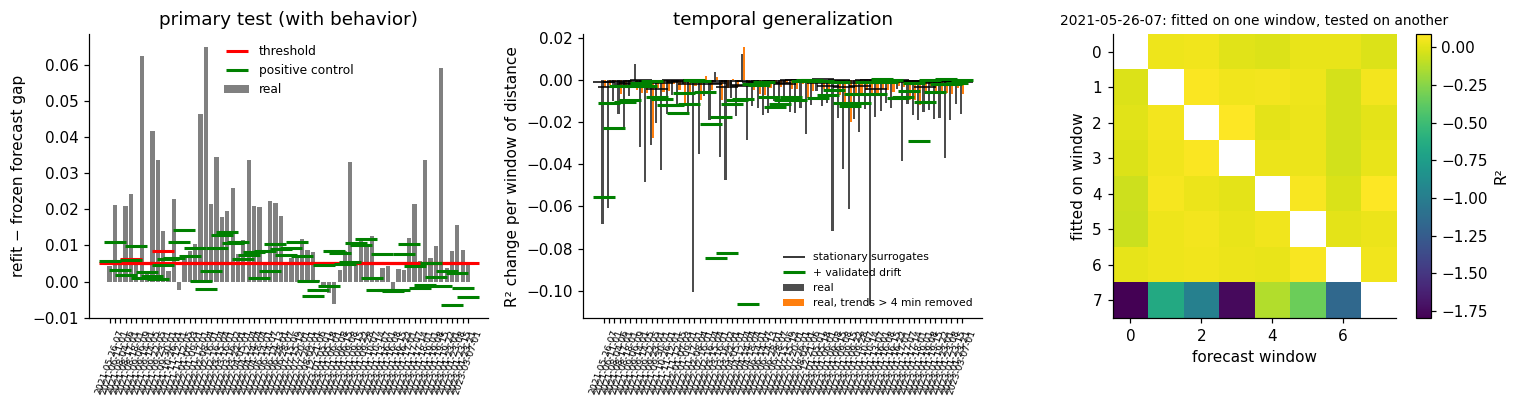

In [7]:
if real_res:
    from collections import Counter
    names = list(real_res)
    print("verdicts:", dict(Counter(real_res[n]["verdict"] for n in names)))
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
    x = np.arange(len(names))
    ax[0].bar(x, [real_res[n]["gap"] for n in names], color="0.5", label="real")
    ax[0].plot(x, [real_res[n]["gap_min_r"] for n in names], "r_", ms=14, mew=2, label="threshold")
    ax[0].plot(x, [real_res[n]["gap_pos"] for n in names], "g_", ms=14, mew=2, label="positive control")
    ax[0].set_ylabel("refit − frozen forecast gap"); ax[0].set_title("primary test (with behavior)"); ax[0].legend(frameon=False, fontsize=8)
    ax[1].bar(x - 0.2, [real_res[n]["tg"] for n in names], 0.4, color="0.3", label="real")
    ax[1].bar(x + 0.2, [real_res[n]["tg_detrended"] for n in names], 0.4, color="tab:orange", label="real, trends > 4 min removed")
    ax[1].plot(x, [min(real_res[n]["tg_null"]) if real_res[n]["tg_null"] else np.nan for n in names], "k_", ms=14, label="stationary surrogates")
    ax[1].plot(x, [real_res[n]["tg_pos"] for n in names], "g_", ms=14, mew=2, label="+ validated drift")
    ax[1].set_ylabel("R² change per window of distance"); ax[1].set_title("temporal generalization"); ax[1].legend(frameon=False, fontsize=7)
    G0 = np.array(real_res[names[0]]["G"])
    im = ax[2].imshow(G0, cmap="viridis"); plt.colorbar(im, ax=ax[2], label="R²")
    ax[2].set_xlabel("forecast window"); ax[2].set_ylabel("fitted on window"); ax[2].set_title(f"{names[0][-13:]}: fitted on one window, tested on another", fontsize=9)
    for a in ax[:2]:
        a.set_xticks(x); a.set_xticklabels([n[-13:] for n in names], rotation=70, fontsize=6)
    plt.tight_layout(); plt.show()

In [8]:
out = {"gap_min": GAP_MIN, "null_gaps": null, "verdicts": V, "valid": bool(VALID),
       "synthetic": {f"{k}_s{s}": {kk: v for kk, v in r.items() if kk != "per_window"} for (k, s), r in results.items()},
       "real": {f: {kk: v for kk, v in r.items() if kk not in ("per_window",)} for f, r in real_res.items()}}
json.dump(out, open(os.path.join(RESULTS, f"E3_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E3_result{TAG}.json")

saved E3_result_laptop.json


### Results of the `laptop` run (2026-10-07; 68 recordings from Atanas et al. 2023)

**§1 Synthetic validation: valid, 9/9** (re-run with the revised fitting). Absorption for self-programming worms was 0.61–1.18; for rewired worms 0.21–0.35, against the 0.5 threshold.

**§3 Real recordings** (120–153 neurons each, no neuron identities, so all-to-all coupling; about 16–17 min each):

| | result |
|---|---|
| **pre-registered verdicts** | **47 rewired**, 11 stationary, 10 stationary (low power), **0 self-programming** |
| drift gap ≥ the recording's surrogate threshold | 48/68; median gap +0.009 (IQR +0.005 to +0.021) |
| power (positive control detected) | 34/68, so the "stationary" verdicts are weak evidence |
| absorption by a meta-program (d = 4), drifting recordings | median **−0.04**, max 0.25, negative in 30/48 |
| temporal generalization: programs go stale with distance | 65/68 beyond the stationary surrogates (median slope −0.016 vs −0.0004 per window) |
| … after removing trends slower than 4 min | still beyond the surrogates in 58/68, with about 28% of the effect left (median −0.005) |
| staleness of a program fitted on the first half | negative in 60/68 (median −0.014 per window) |

**Interpretation.**
* Spontaneous whole-brain dynamics in *C. elegans* are **not stationary over 16 minutes**: a program fitted on the past goes stale, in most animals and well beyond what the same program produces as a stationary process.
* Most of the staleness lives in slow (> 4 min) changes, but a clear part does not.
* **No compact, activity-driven meta-program absorbs the drift.** Absorption is often negative: slow states learned from the past extrapolate worse than ignoring them. In the pre-registered terms, the program/hardware distinction fails here *within this model class*.

**What "rewired" does not yet exclude:**
1. slow **behavioral state** (roaming vs dwelling): behavior entered only as instantaneous inputs;
2. changes in **how neurons encode behavior**, which Atanas et al. reported in specific neurons and which a drive-modulating meta-program cannot represent;
3. slow imaging changes.

Notebook 11 (E3b) tests 1 and 2.

> **Follow-up (added 2026-10-08): what Notebooks 11–14 found.**
> * **1 · slow behavioral state:** no (11).
> * **2 · encoding changes in identified neurons:** no (11).
> * **3 · slow imaging changes:** no. Drift does not track signal fading, and measurement corrections make forecasts worse (12).
>
> What drifts is each neuron's drive, independently, with no gain, low-rank or coupling structure detectable (12). The drives wander like a random walk rather than returning to set points within ~17 min, and one online error-driven rule tracks them (13).
>
> All of this holds against realistic **colored-noise** nulls, not only the white-noise surrogates used here: gap, staleness and tracker gain exceed them in 62, 64 and 66 of 68 recordings (14).

## 4 · Reading the result

| real-data verdict | meaning for C3 (proposal §5) |
|---|---|
| stationary | over ~17 min, a program fitted on the past keeps forecasting as well as a rewritten one: the computer metaphor is defensible on this timescale, for the fast dynamics that one-step forecasts measure |
| stationary (low power) | the test could not have detected drift of the validated size on this recording: no conclusion |
| self_program | drift exists but is absorbed by a few slow, activity-driven states: the brain is a *self-programming* machine; the program/hardware split survives with a compact meta-program |
| rewired | drift no compact meta-program absorbs: within this model class, the program/hardware distinction fails (Brette's position), *after* checking that behavioral state does not explain it |

**Reading the diagnostics together.** A strongly negative temporal-generalization slope with a stationary primary verdict means: programs fitted on *short* stretches go stale (they absorb that stretch's baseline levels), while a program fitted on *longer* data does not. If detrending removes most of the slope, the drift lives in slow baseline levels rather than in the fast dynamics, which motivates E3b: a slow-state model of baseline levels, with behavioral state (roaming/dwelling) as the first candidate explanation.

**Limits.** One model class: the slow states only modulate drives, not weights. A rewired verdict therefore means "not absorbed by drive-modulating states", which motivates a version with weight-modulating states. The synthetic truths share the model's own form, which makes validation a necessary, not a sufficient, check.